In [1]:
# importing the required libraries
import numpy as np   
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt   
import seaborn as sns
%matplotlib inline 

In [2]:
# reading the CSV file into pandas dataframe
mpg_df = pd.read_csv("cars-dataset.csv")  

In [3]:
# checking the data set
mpg_df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [4]:
mpg_df.info()
mpg_df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [5]:
# non-numerical value is present in the HP column.. Finding that
temp = pd.DataFrame(mpg_df.hp.str.isdigit()) 
temp[temp['hp'] == False]

,hp
32,False
126,False
330,False
336,False
354,False
374,False


In [9]:
#converting the HP data type to float
mpg_df['hp'] = mpg_df['hp'].astype('float64')

In [11]:
# dropping the car name columns
mpg_df = mpg_df.drop('car name', axis=1)
mpg_df.head()

,cyl,disp,hp,wt,acc,yr,mpg
0,8,307.0,130.0,3504,12.0,70,18.0
1,8,350.0,165.0,3693,11.5,70,15.0
2,8,318.0,150.0,3436,11.0,70,18.0
3,8,304.0,150.0,3433,12.0,70,16.0
4,8,302.0,140.0,3449,10.5,70,17.0


In [12]:
#replacing the ? with NAN
mpg_df = mpg_df.replace('?', np.nan)
mpg_df = mpg_df.apply(lambda x: x.fillna(x.median()),axis=0)

In [13]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
cyl     398 non-null int64
disp    398 non-null float64
hp      398 non-null float64
wt      398 non-null int64
acc     398 non-null float64
yr      398 non-null int64
mpg     398 non-null float64
dtypes: float64(4), int64(3)
memory usage: 21.8 KB


C:\Users\selvm\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


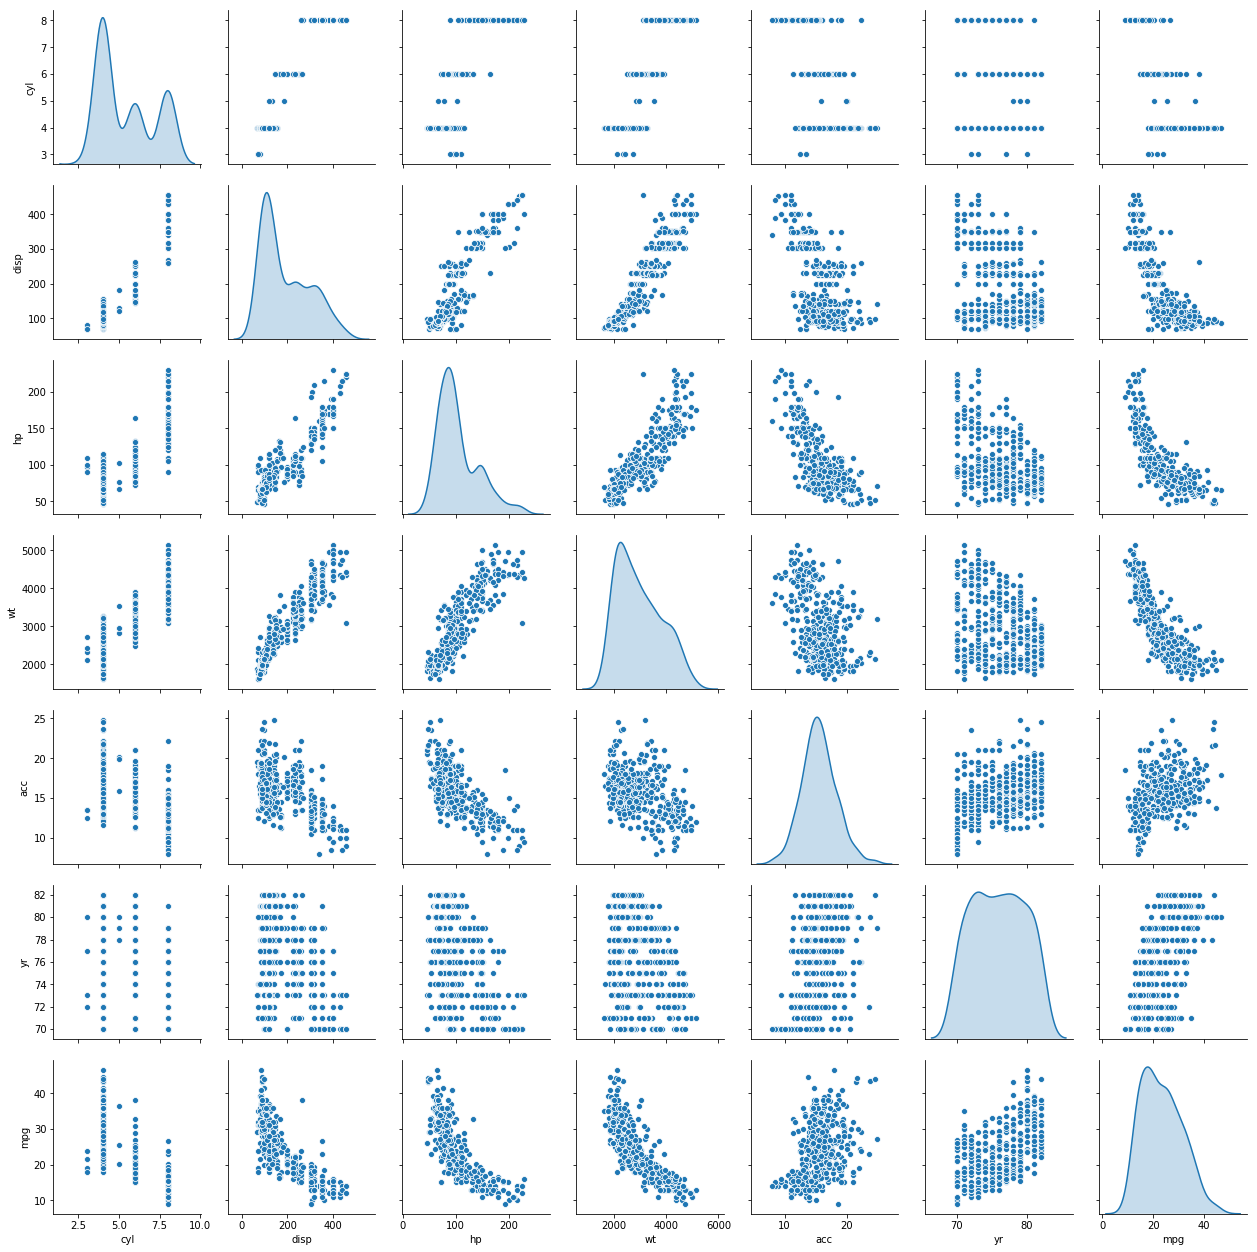

In [14]:
#Plotting the pair plot graph and finding the relationship 
sns.pairplot(mpg_df,diag_kind='kde')


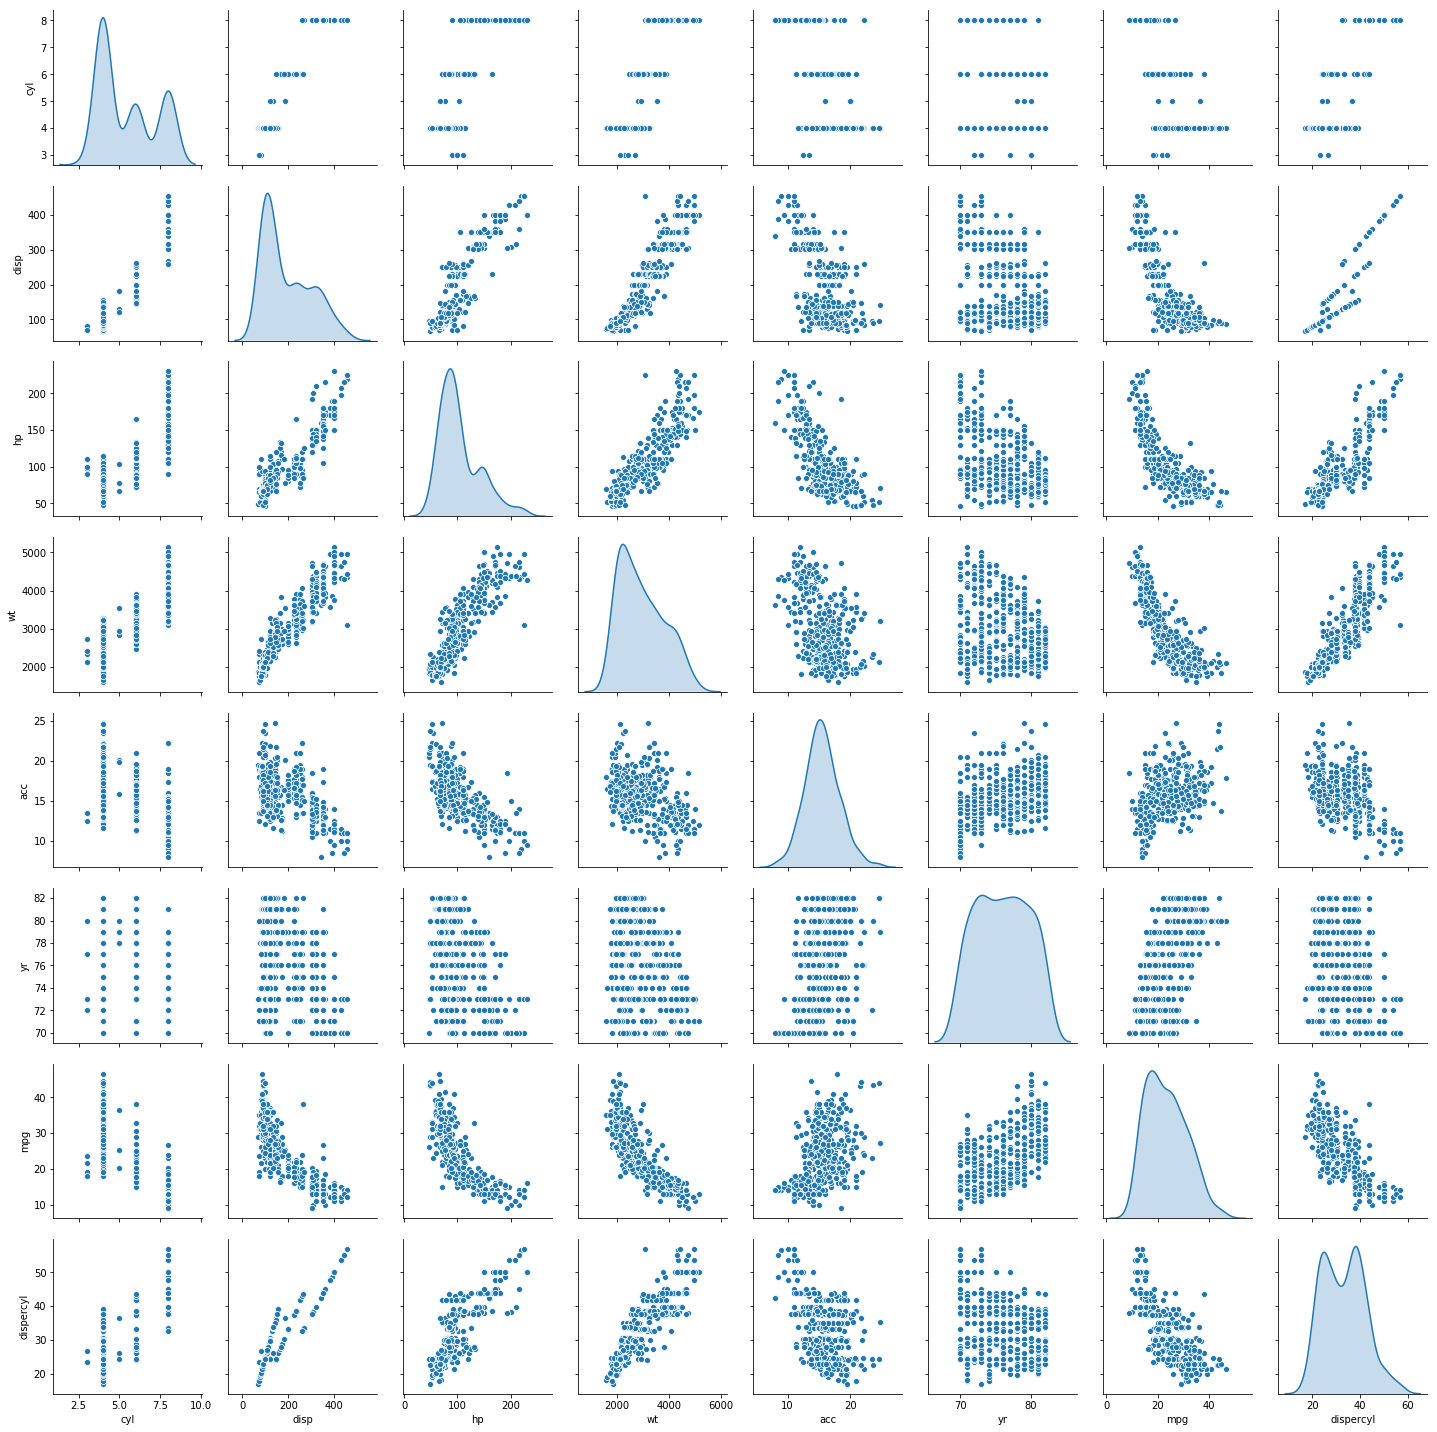

In [15]:
mpg_df['dispercyl'] = mpg_df['disp'] / mpg_df['cyl']
sns.pairplot(mpg_df, diag_kind='kde')

In [16]:
from scipy.stats import zscore

mpg_df_attr = mpg_df.loc[:, 'cyl':'mpg']
mpg_df_attr_z = mpg_df_attr.apply(zscore)

print(mpg_df_attr_z)

# Remove "yr" column
mpg_df_attr_z.pop('yr')

array = mpg_df_attr_z.values

          cyl      disp        hp        wt       acc        yr       mpg
0    1.498191  1.090604  0.673118  0.630870 -1.295498 -1.627426 -0.706439
1    1.498191  1.503514  1.589958  0.854333 -1.477038 -1.627426 -1.090751
2    1.498191  1.196232  1.197027  0.550470 -1.658577 -1.627426 -0.706439
3    1.498191  1.061796  1.197027  0.546923 -1.295498 -1.627426 -0.962647
4    1.498191  1.042591  0.935072  0.565841 -1.840117 -1.627426 -0.834543
5    1.498191  2.262118  2.454408  1.620492 -2.021656 -1.627426 -1.090751
6    1.498191  2.502182  3.030708  1.635863 -2.384735 -1.627426 -1.218855
7    1.498191  2.367746  2.899730  1.586204 -2.566274 -1.627426 -1.218855
8    1.498191  2.511784  3.161685  1.719809 -2.021656 -1.627426 -1.218855
9    1.498191  1.887617  2.244844  1.039961 -2.566274 -1.627426 -1.090751
10   1.498191  1.820399  1.720935  0.700628 -2.021656 -1.627426 -1.090751
11   1.498191  1.407489  1.458981  0.755016 -2.747814 -1.627426 -1.218855
12   1.498191  1.983643  1.197027  0.9

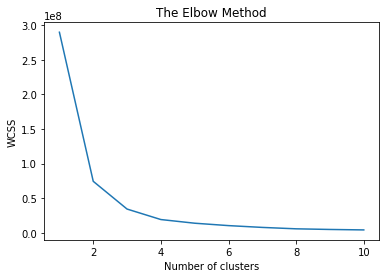

In [17]:
# Using the elbow method to find  the optimal number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(mpg_df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [18]:
# Based on the elbow method choosing number of clusters as 3
km = KMeans(n_clusters=3, #Number of clusters
            n_init=10, #How many times KMeans will be run with random centroid starts
            max_iter=300) #Maximum iterations

In [19]:
cluster_range = range( 2, 6)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(mpg_df_attr)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )

In [20]:
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,7.428941e+07
1,3,3.420799e+07
2,4,1.905160e+07
3,5,1.376385e+07


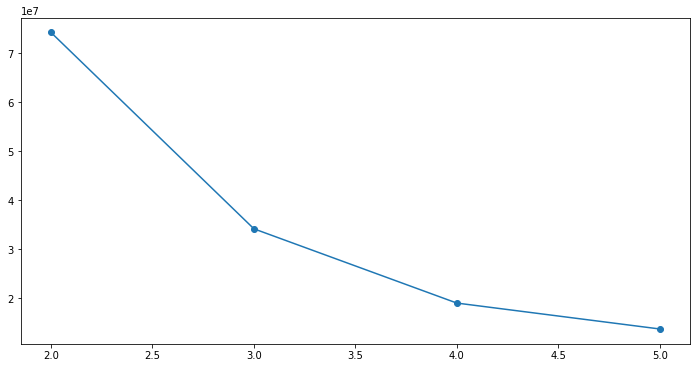

In [21]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [22]:
cluster = KMeans( n_clusters = 3, random_state = 2354 )
cluster.fit(mpg_df_attr_z)
mpg_df_attr_z_copy = mpg_df_attr_z.copy(deep = True)  # Creating a mirror copy for later re-use instead of building repeatedly

In [23]:
centroids = cluster.cluster_centers_
centroids

array([[ 1.4860546 ,  1.48450715,  1.50624078,  1.38753374, -1.06267868,
        -1.15110476],
       [-0.85347696, -0.80321374, -0.67506194, -0.78549879,  0.36133415,
         0.75394661],
       [ 0.34598334,  0.23689416, -0.06773972,  0.29795187,  0.30089004,
        -0.47244453]])

In [24]:
centroid_df = pd.DataFrame(centroids, columns = list(mpg_df_attr_z) )
centroid_df

,cyl,disp,hp,wt,acc,mpg
0,1.486055,1.484507,1.506241,1.387534,-1.062679,-1.151105
1,-0.853477,-0.803214,-0.675062,-0.785499,0.361334,0.753947
2,0.345983,0.236894,-0.067740,0.297952,0.300890,-0.472445


In [25]:
prediction=cluster.predict(mpg_df_attr_z)
mpg_df_attr_z["GROUP"] = prediction     
# Creating a new column "GROUP" which will hold the cluster id of each record

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001ED5DE72358>,
      dtype=object)

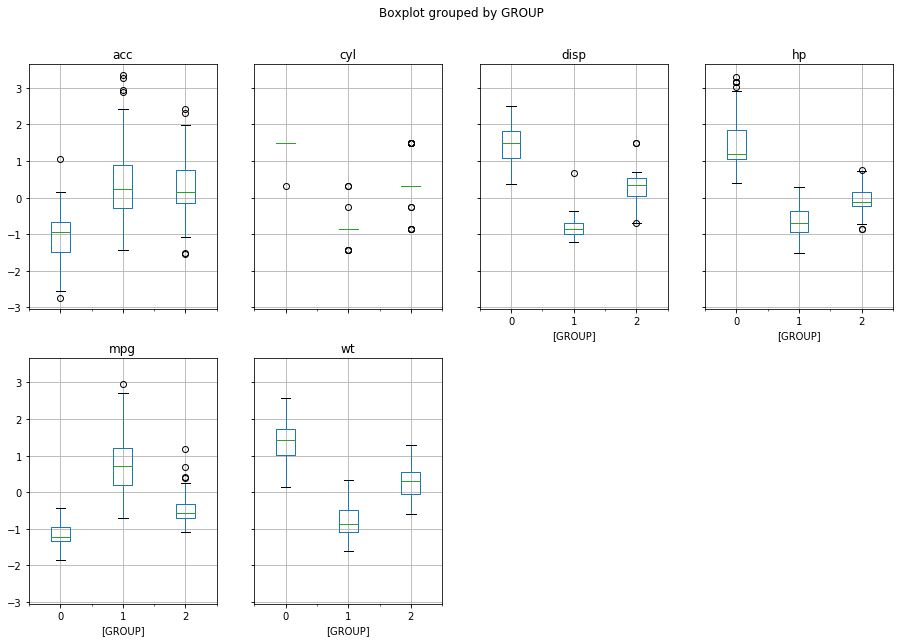

In [26]:
import matplotlib.pylab as plt

mpg_df_attr_z.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 10))
